# A Unifying Valuation Framework for Variable Annuities
### GMDB · GMAB · GMWB — Three-Floor Design (S and S+S)

This note presents a single, coherent contract/payoff framework for variable annuities with
guarantees. It synthesises Bacinello et al. (2011) and Fontana & Rotondi (2023) under one deliberate
design principle: **contractual death and terminal benefits are never penalised; the only behavioural
event that incurs a charge is surrender.**

**Scope.**
- Three guarantee types — **GMDB**, **GMAB**, **GMWB** (GMIB excluded).
- Only the **static (S)** and **static + surrender (S+S, "mixed")** schemes.
- Withdrawals are always contractual (the guaranteed amount $g$). Dynamic optimisation (D) is out of
  scope.

**Penalty.** A single flat parameter $p_S$ — the **surrender charge**, applied uniformly to the
maximum of the account value and the surrender floor. There is **no excess-withdrawal penalty** ($\beta$):
in the S/S+S settings the policyholder never withdraws more than $g$, contractual death/terminal
benefits are paid in full, and the surrender charge alone prices behavioural early exit. This is a
deliberate departure from Fontana's penalised base at death/terminal/surrender.

---

## 1. Notation and market model

- Single premium $P$ at time $0$; anniversaries $\mathcal{T}=\{1,\dots,N\}$, $N=T$ the maturity; $n^-$
  / $n^+$ denote the instant just before / after the date-$n$ event.
- $(S_t)$ reference fund; $(A_t)$ account value, $A_0=P$.
- $(G^X_t),\,(G^D_t),\,(G^S_t)$ — **three guarantee floors** (living, death, surrender). Each starts at
  $P$ and evolves independently via its own composite mechanism (§3).
- $(r_t)$ short rate; $M_t=\exp(\int_0^t r_u\,du)$ the numéraire; $p(t,T)$ a zero-coupon bond price.
- $\tau_D$ residual lifetime; $\pi_n=\mathbb{Q}(\tau_D>n\mid\tau_D>n-1)$ the one-period survival prob.
- $\alpha$ proportional management fee (Bacinello's $\varphi$); $g$ guaranteed withdrawal, usually $P/N$.

Expectations are under a fixed pricing measure $\mathbb{Q}$. Financial and mortality risks are
independent, so survival enters either through the deterministic weights $\pi_n$ **or** through a
simulated $\tau_D$ (both supported; §7 states which each reproduction uses).

---

## 2. Account and guarantee dynamics

The account follows Bacinello's eq. (4.3):

$$
dA_t=A_t\,\frac{dS_t}{S_t}-\alpha A_t\,dt-dB^{L}_t,\qquad A_0=P,
$$

with $B^{L}_t$ the cumulated **living benefits**. The fee $\alpha$ is deducted **continuously and
proportionally** and is borne by the **account only**. Living benefits are deducted **discretely** and
reduce **the account and every guarantee floor alike**.

Concretely, at each anniversary $n$ let $\Delta B^{L}_n$ be the living benefit paid ($\Delta B^{L}_n=g$
for the GMWB; $0$ for the GMAB until maturity). Then, for the account and for **each** floor
$\bullet\in\{X,D,S\}$:

$$
A_{n^+}=(A_{n^-}-\Delta B^{L}_n)^+,\qquad
G^{\bullet}_{n^+}=G^{\bullet}_{n^-}-\Delta B^{L}_n .
$$

So the same withdrawal that reduces the account reduces **all** floors; the fee touches only the
account. (For the GMAB, $\Delta B^L_n=0$ until $T$, so the floors are unaffected by withdrawals.)

---

## 3. Guarantee floors — composite "max of mechanisms"

Each floor is a composite of elementary **schemes**; its value at an anniversary is the element-wise
maximum over its schemes, evaluated **before** the living benefit is paid (the SU-W convention; see
§10).

### 3.1 Elementary schemes

| Scheme | Update $G_{(n-1)^+}\to G_{n^-}$ |
|------|------|
| **Fixed** | $G_{(n-1)^+}$ (optionally times a factor, e.g. $1-\varepsilon$) |
| **RollUp** | $G_{(n-1)^+}\,e^{\delta\Delta t}$ |
| **Ratchet** | $\max(G_{(n-1)^+},A_{n^-})$ on the scheme's anniversary dates, else unchanged |
| **Reset** | $A_{n^-}$ on reset dates (may decrease) |

A **step-up** (Fontana's SU-W) is exactly `Ratchet` whose date set is *all* anniversaries — so no
separate `StepUp` class is needed.

### 3.2 The three composite floors

A floor is `max` over a list of schemes; all start at $G_0=P$.

- **Living floor $G^X$** — terminal payoffs, and the base reduced by living benefits in the GMWB.
- **Death floor $G^D$** — the death cashflow.
- **Surrender floor $G^S$** — the surrender cashflow.

Putting §2 and §3 together, each floor advances by its own schemes and is then reduced by the common
living benefit:

$$
G^{\bullet}_{n^-}=\max_{\text{schemes}}\big\{\text{scheme.update}(G^{\bullet}_{(n-1)^+},A_{n^-})\big\},
\qquad
G^{\bullet}_{n^+}=G^{\bullet}_{n^-}-\Delta B^{L}_n .
$$

A separable **GMDB** (only meaningful on a GMAB) is *not* a separate cashflow object — it is simply an
independent death floor $G^D\neq G^X$, e.g. `Floor([RollUp, Ratchet])` (Bacinello's eq. (3.7)).

---

## 4. Products and their cashflow methods

Two concrete products implement the abstract cashflow methods of the base class, replacing the old
list-of-riders design.

### 4.1 GMAB
- **living** $=0$ throughout; at $T$ the terminal cashflow is paid.
- **terminal** $=\max(A_T,\,G^X_T)$.
- **death** $=\max(A_{n^-},\,G^D_{n^-})$. Default $G^D=$ `Fixed(0)` $\Rightarrow\max(A_{n^-},0)$ (return
  of account); attach an independent $G^D$ for a separable GMDB.
- **surrender** — §5.

### 4.2 GMWB
- **living** $=g$ at each anniversary $n=1,\dots,N$.
- **terminal** (date $N$): the **last withdrawal $g$ is paid in addition** to the residual guarantee:

$$
\text{cashflow}_N \;=\; g \;+\; \max\big(A_{N^+},\,G^X_{N^+}\big),
\qquad A_{N^+}=(A_{N^-}-g)^+,\ \ G^X_{N^+}=G^X_{N^-}-g .
$$

  When both $A_{N^-},G^X_{N^-}\ge g$ this equals $\max(A_{N^-},G^X_{N^-})$ — i.e. Fontana's eq. (4) with
  $\beta=0$, consistent with the no-penalty-at-terminal principle.
- **death** $=\max(A_{n^-},\,G^D_{n^-})$. With $G^D=$ `Fixed(P)`, the §2 reduction gives
  $G^D_{n^-}=P-(n-1)g=$ the **nominal sum of remaining guaranteed withdrawals** — an undiscounted
  analogue of Bacinello's $R_t$.
- **surrender** — §5 (Bacinello withdrawal-date specialisation included).

---

## 5. Per-event cashflows — unified formulas

All paid at the anniversary date unless stated.

**Living.** $\ \text{living}_n=g$ (GMWB) or $0$ (otherwise).

**Death** (death in $(n-1,n]$). No penalty, no discounting:

$$
\text{death}_n=\max\big(A_{n^-},\,G^D_{n^-}\big).
$$

**Terminal** (date $N$). GMAB: $\max(A_T,G^X_T)$. GMWB: $g+\max(A_{N^+},G^X_{N^+})$ (§4.2).

**Surrender** (anniversary $n$, before the living benefit). A single homogeneous charge $p_S$ on the
elected maximum:

$$
\;\text{surrender}_n=(1-p_S)\,\max\big(A_{n^-},\,G^S_{n^-}\big)\;
$$

- **Bacinello-style (account-only):** set $G^S=$ `Fixed(0)` $\Rightarrow (1-p_S)\,A_{n^-}$. For the
  **GMWB on a withdrawal date**, pay $g$ in full first and charge only the residual account:
  $\ g+\max(A_{n^-}-g,0)(1-p_S)$.
- **Fontana-style (guarantee-floored):** set $G^S=G^X$ and $p_S=0$ $\Rightarrow\max(A_{n^-},G^X_{n^-})$.
  Note this is Fontana's surrender **with $\beta=0$** (no excess penalty) — see §7.2.

The surrender flavour is selected entirely by the **choice of $G^S$**; there is no $\theta$ toggle.

---

## 6. Valuation

With surrender time $\tau_S$, the time-0 value net of fees is

$$
V_0=\sup_{\tau_S}\,\mathbb{E}\!\left[\sum_{n=1}^{N\wedge\tau_S}
\Big(\mathbb{1}_{\{\tau_D>n\}}\,\text{living}_n+\mathbb{1}_{\{n-1<\tau_D\le n\}}\,\text{death}_n\Big)\frac{M_0}{M_n}
+\mathbb{1}_{\{\tau_D>\tau_S\}}\,\text{surrender}_{\tau_S}\frac{M_0}{M_{\tau_S}}\right],
$$

where at $n=N$ the living term is replaced by the date-$N$ cashflow $g+\max(A_{N^+},G^X_{N^+})$ (the
last withdrawal **plus** the terminal), and no surrender occurs at $N$.

- **S:** $\tau_S\equiv\infty$; the supremum vanishes — ordinary Monte Carlo.
- **S+S:** $\tau_S\in\{1,\dots,N-1\}$; optimal stopping — Least-Squares Monte Carlo (§8).

The contract is fairly priced when $V_0(\alpha)=P$; the fair fee $\alpha^*$ solves this. By
construction $V_0^{S}\le V_0^{S+S}$, hence $\alpha^{*,S}\le\alpha^{*,S+S}$.

---


## 8. Numerical method for S+S (Least-Squares Monte Carlo)

The mixed valuation is an optimal stopping problem solved by Longstaff–Schwartz:

1. **Simulate** $H$ joint paths of $(S_t, r_t, K_t, \mu_t, A_t, G^X_t, G^D_t, G^S_t, \tau_D)$ on the
   anniversary grid under $\mathbb{Q}$. The guarantee paths are precomputed in a **forward pass**
   because withdrawals are contractual.
2. **Backward** from $n=N-1$ to $1$: on each admissible date, restrict to paths alive and not yet
   surrendered; form the discounted realised continuation value $C_n$; regress $C_n$ on the basis
   below to get $\widehat C_n$; compute $\text{surrender}_n$ (GMWB Bacinello mode → withdrawal-date
   specialisation); surrender where $\text{surrender}_n>\widehat C_n$, zeroing subsequent cashflows on
   those paths.
3. At $N$, the cashflow is the last withdrawal plus the terminal (§4.2). The price is the average of
   discounted cashflows.

**Regression basis.** Bacinello employs the four state variables $(A, r, K, \mu)$ with polynomial basis
functions up to **degree 4**; we adopt the same set and add the surrender floor $G^S$:

$$
\text{basis} = \text{polynomials up to degree } 4 \text{ in }
\Big\{\,A_{n^-}/P,\ r_n,\ K_n,\ \mu_n,\ G^S_{n^-}/P\,\Big\}.
$$

Terms drop out automatically by configuration: $K$ when fund volatility is deterministic (Fontana's
HW), $\mu$ when mortality is deterministic ($\pi_n$ weighting), and $G^S/P$ is degenerate in Bacinello
mode ($G^S\equiv0$) but **essential** in Fontana mode and whenever step-up makes $G^X$ stochastic.
Including $r$ is essential under stochastic rates. Because withdrawals are fixed, the decision is a
binary stop — exactly where LSMC is reliable.

---

## 9. Code structure (schematic)

```python
# ── Guarantee schemes ──────────────────────────────────────────────
class GuaranteeScheme(ABC):
    @abstractmethod
    def update(self, G_prev, A_now, t, dt):
        ...


class Fixed(GuaranteeScheme):
    def __init__(self, multiplier=1.0):
        ...  # G_prev * multiplier


class RollUp(GuaranteeScheme):
    def __init__(self, delta):
        ...


class Ratchet(GuaranteeScheme):
    def __init__(self, dates):
        ...  # step-up = Ratchet(all anniversaries)


class Reset(GuaranteeScheme):
    def __init__(self, dates):
        ...


class GuaranteeFloor:
    def __init__(self, schemes, G0=1.0):
        self.schemes, self.G0 = schemes, G0

    def step(self, G_prev, A_now, t, dt):  # max over schemes
        return reduce(
            torch.maximum, (s.update(G_prev, A_now, t, dt) for s in self.schemes)
        )


# ── Base annuity: VALUATION machinery + uniform cashflow defaults ──
class GMxBAnnuity(BaseDerivative, ABC):
    def __init__(
        self,
        fund,
        living_floor,
        death_floor=None,
        surrender_floor=None,
        premium=1.0,
        maturity=10.0,
        p_S=0.0,
        mortality_process=None,
        surrender_schedule=None,
    ):
        # death_floor   default -> Floor([Fixed(0)])  (no death guarantee)
        # surrender_floor default -> Floor([Fixed(0)]) (account-only / Bacinello)
        ...

    @abstractmethod
    def living_cashflow(self, t, A, G_X):
        ...

    @abstractmethod
    def terminal_cashflow(self, A_plus, G_X_plus):
        ...

    def death_cashflow(self, t, A, G_D):  # no penalty, no discount
        return torch.maximum(A, G_D)

    def surrender_cashflow(self, t, A, G_S):  # homogeneous charge
        return (1.0 - self.p_S) * torch.maximum(A, G_S)

    # _account_paths, _floor_paths (forward), _static_price_grid,
    # _mixed_price_grid (LSMC), fair_fee live here.


# ── Concrete products ──────────────────────────────────────────────
class GMABAnnuity(GMxBAnnuity):
    def living_cashflow(self, t, A, G_X):
        return zeros_like(A)

    def terminal_cashflow(self, A_plus, G_X_plus):
        return torch.maximum(A_plus, G_X_plus)


class GMWBAnnuity(GMxBAnnuity):
    def __init__(self, *a, bacinello_mode=False, **k):
        super().__init__(*a, **k)
        self.bacinello_mode = bacinello_mode

    def living_cashflow(self, t, A, G_X):
        return full_like(A, self.g) if t in self.schedule else zeros_like(A)

    def terminal_cashflow(self, A_plus, G_X_plus):  # added on top of last g in the loop
        return torch.maximum(A_plus, G_X_plus)

    def surrender_cashflow(self, t, A, G_S):
        if (
            self.bacinello_mode and t in self.schedule
        ):  # pay g first, charge the residual
            return self.g + torch.clamp(A - self.g, min=0.0) * (1.0 - self.p_S)
        return super().surrender_cashflow(t, A, G_S)

```

The old `List[GuaranteeBase]`, the `db_riders / lb_riders` ternary, and the $\theta$ toggle are all
gone. Product identity and guarantee composition are **structural**, not runtime checks.

---

## 10. Design choices and simplifications

- **No penalty on contractual death or terminal benefits.** Death and maturity are not behavioural
  choices; the guarantee is paid in full. Deliberate departure from Fontana's penalised base.
- **No excess-withdrawal penalty ($\beta$).** Only static withdrawals (exactly $g$) are considered, so
  the parameter is unnecessary; surrender is priced solely by the charge $p_S$.
- **All floors reduced by living benefits.** The same $B^L$ that reduces the account reduces every
  floor; only the account bears the continuous fee $\alpha$. This makes `Fixed(P)` death/surrender
  floors equal the nominal remaining guarantee, $P-(n-1)g$.
- **Homogeneous surrender charge.** $\text{surrender}_n=(1-p_S)\max(A,G^S)$ — one rate on the whole
  elected amount, no asymmetric penalties on account vs base.
- **No $\theta$ toggle.** Bacinello vs Fontana surrender is the choice of $G^S$ (`Fixed(0)` vs $G^X$);
  the Bacinello withdrawal-date case is a flag inside the GMWB product.
- **Ratchet and step-up unified** as one scheme parameterised by its anniversary set.
- **SU-W convention.** The step-up/floor update is applied **before** the withdrawal. Under static
  withdrawals this coincides with W-SU except when the account is near exhaustion
  ($A_{n^-}<g\le G^X_{n^-}$); the difference is immaterial for the static columns. Kept fixed.
- **Naming.** All payoff methods are prefixed `*_cashflow`, mapping directly to $X_n$, $X_n^D$,
  $X_n^S$, $X_N$.


In [1]:
import numpy as np, torch, os, sys, math, tempfile
from functools import partial
import matplotlib.pyplot as plt
from matplotlib import cm

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
SRC = os.path.join(ROOT, "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)
torch.set_num_threads(4)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

# ── stochastic factors, market, products (current qabit API) ──────────────────
from qabit import (
    SDESystem,
    GeometricBrownianFactor,
    VasicekRateFactor,
    EventCalendar,
    Market,
    DiscountCurve,
    VolSurface,
    ExponentialHazardFactor,
    GompertzHazardFactor,
    WeibullHazardFactor,
    CIRExponentialHazardFactor,
    CIRGompertzHazardFactor,
    CIRWeibullHazardFactor,
)
from qabit.core.market.curve import (
    MarketKeys,
    StochasticDiscountCurve,
    StochasticHazardCurve,
    HazardCurve,
)
from qabit.core.products.underlying.composite.fund import Fund
from qabit.core.products.derivatives.va import (
    GuaranteeFloor,
    Fixed,
    RollUp,
    Ratchet,
    Reset,
    GMABAnnuity,
    GMWBAnnuity,
    GMDBAnnuity,
    GMxBAnnuity,
)
from qabit.core.analytics.hazard import (
    exponential_hazard,
    gompertz_hazard,
    weibull_hazard,
    survival as hz_survival,
    density as hz_density,
    expected_lifetime as hz_expected_lifetime,
)
from qabit.core.analytics.equity.black_scholes import bs_put_scalar

# palette
B, O, G, P_, GREY, PURP = "#378ADD", "#D85A30", "#1D9E75", "#7F77DD", "#9aa0a6", "#9C27B0"

# scratch directory for any figure exports
TMP = tempfile.gettempdir()

# annuitant entry age (years) — used by the Gompertz/Weibull laws
ENTRY_AGE = 60.0


def world(T=10.0):
    """A stochastic-rate, flat-vol world: a GBM equity driven by a Vasicek short
    rate, with an OIS discount curve read straight off the simulated rate."""
    sde = SDESystem(
        {
            "eq": GeometricBrownianFactor(sigma=0.18, s0=1.0, rate="rate"),
            "rate": VasicekRateFactor(kappa=0.5, theta=0.03, sigma=0.01, r0=0.03),
        }
    )
    sde.simulate(EventCalendar.from_horizon(T + 0.5, 1 / 12), n_paths=12000, seed=11)
    mkt = Market(
        discount={"ois": StochasticDiscountCurve(sde["rate"])},
        volatility={"v": VolSurface.flat(0.18)},
    )
    return sde, mkt





# Convenience guarantee-floor menu used in the floor-mechanism figure.
FLOORS = {
    "fixed": [Fixed()],
    "ratchet": [Ratchet()],
    "reset": [Reset(dates=[3.0, 6.0])],
    "roll-up 3%": [RollUp(0.03)],
}

## 1. Guarantee floor mechanisms

A `GuaranteeFloor` is a list of schemes whose single-step value is the
element-wise maximum across them, evaluated *before* any living benefit is
paid. Each elementary scheme advances $G_{(n-1)^+} \to G_{n^-}$ at an anniversary:

* `Fixed(multiplier=1)`     — flat (or geometric) growth.
* `RollUp(delta)`           — continuous roll-up: $G \leftarrow G\,e^{\delta\,dt}$.
* `Ratchet(dates=None)`     — $G \leftarrow \max(G, A)$ on the listed dates
  (`dates=None` = every anniversary, i.e. a *step-up*).
* `Reset(dates)`            — $G \leftarrow A$ on the listed dates (can decrease).


 

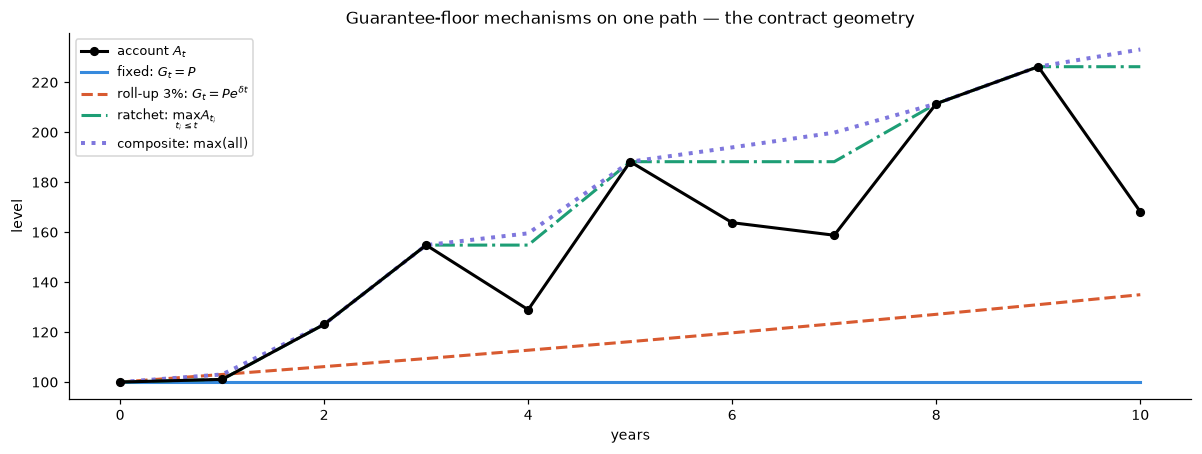

In [2]:
# One sample path of the fund, with each guarantee-floor mechanism materialised
# on top of it — the contract geometry behind every payoff below.
sde = SDESystem({"eq": GeometricBrownianFactor(sigma=0.20, s0=100.0, mu=0.06, rate=None)})
sde.simulate(EventCalendar.from_horizon(T=10.0, dt=1.0), n_paths=1, seed=7)
A = sde["eq"].get_state().paths[0].float().numpy()
t = sde["eq"].get_state().dates.float().numpy()


def materialise(floor):
    Gv = float(floor.G0)
    out = [Gv]
    for k in range(1, len(A)):
        dt = float(t[k] - t[k - 1])
        Gv = float(
            floor.step(torch.tensor([Gv]), torch.tensor([float(A[k])]), float(t[k]), dt)[0]
        )
        out.append(Gv)
    return np.array(out)


fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(t, A, "k-o", lw=2, ms=5, zorder=5, label=r"account $A_t$")
ax.plot(t, materialise(GuaranteeFloor([Fixed()], G0=100.0)), color=B, lw=2,
        label=r"fixed: $G_t=P$")
ax.plot(t, materialise(GuaranteeFloor([RollUp(delta=0.03)], G0=100.0)), color=O, lw=2,
        ls="--", label=r"roll-up 3%: $G_t=P e^{\delta t}$")
ax.plot(t, materialise(GuaranteeFloor([Ratchet()], G0=100.0)), color=G, lw=2, ls="-.",
        label=r"ratchet: $\max_{t_i\leq t} A_{t_i}$")
ax.plot(t, materialise(GuaranteeFloor([Fixed(), RollUp(delta=0.03), Ratchet()], G0=100.0)),
        color=P_, lw=2.6, ls=":", label="composite: max(all)")
ax.set_xlabel("years"); ax.set_ylabel("level")
ax.set_title("Guarantee-floor mechanisms on one path — the contract geometry")
ax.legend(fontsize=8.5); fig.tight_layout(); plt.show()

## Six mortality models

Each `MortalityModel` binds a hazard law to its qabit `Factor`: a deterministic
intensity (degenerate paths) or a CIR-stochastic intensity reverting to that
law. It exposes the analytical `survival(t)`, `density(t)` and
`expected_lifetime(t)` (closed forms below) and draws Monte-Carlo death times
`simulate_death_times()` from the simulated intensity via the `SDESystem`.

**Closed forms:**

| Model | $S(t)$ | Notes |
|-------|--------|-------|
| Exponential | $e^{-\lambda_0 t}$ | Memoryless: $\mathbb{P}(\tau > t+s \mid \tau > s) = \mathbb{P}(\tau > t)$ |
| Gompertz | $\exp\!\left[e^{(x-m)/b}\bigl(1 - e^{t/b}\bigr)\right]$ | Best empirical fit for ages 40–90 |
| Weibull | $\exp\!\left[-(t/c_1)^{c_2}\right]$ | Flexible shape via $c_2$ (increasing if $>1$) |
| CIR-* | no closed form — numerical | Systematic longevity uncertainty |

### Death-time validation — MC histogram vs $f(t)$

Consistency test: simulate $N$ paths of $\tau$ by integrated-hazard inversion
($\tau = \inf\{t : \int_0^t \lambda\,ds > E\}$, $E\sim\mathrm{Exp}(1)$), build an
empirical histogram, and overlay the analytical density $f(t)=\lambda(t)\,S(t)$.
The histogram $L^1$ error is $O(N^{-1/2})$ per bin; with $N=50{,}000$ paths the
fit is visually indistinguishable from the density.

In [3]:
from torch import Tensor


class MortalityModel:
    """Notebook adapter binding a deterministic hazard *law* (and its qabit
    Factor) to the qabit analytics — recreating the rich interface the retired
    ``HazardProcess`` objects exposed:

    * closed-form survival / density / E[tau] / lambda on a years-since-inception grid;
    * Monte-Carlo death times drawn from the simulated intensity via an
      ``SDESystem`` and ``StochasticHazardCurve`` (genuinely stochastic for the
      CIR variants, degenerate for the deterministic ones).

    The factor is the *only* simulation object; this wrapper is pure notebook
    glue so the Titanic/GMDB analyses read as they did before the Process→Factor
    rename.
    """

    def __init__(self, label, color, hazard_fn, factor):
        self.label, self.color = label, color
        self.hazard_fn, self.factor = hazard_fn, factor
        self._sde = None
        self._curve = None

    @staticmethod
    def _t(t):
        return t if torch.is_tensor(t) else torch.as_tensor(t, dtype=torch.float32)

    # ── closed-form survival family (deterministic target law) ────────────────
    def hazard_rate(self, t):
        return self.hazard_fn(self._t(t))

    def survival(self, t):
        t = self._t(t)
        return hz_survival(t, self.hazard_fn(t))

    def density(self, t):
        t = self._t(t)
        return hz_density(t, self.hazard_fn(t))

    def expected_lifetime(self, t):
        t = self._t(t)
        return hz_expected_lifetime(t, self.hazard_fn(t))

    # ── Monte-Carlo death times via the SDESystem ─────────────────────────────
    def simulate(self, dates, n_paths, seed=11):
        cal = EventCalendar(self._t(dates))
        sde = SDESystem({"mort": self.factor})
        sde.simulate(cal, n_paths=n_paths, seed=seed)
        self._sde = sde  # keep alive: factor views hold only a weakref
        self._curve = StochasticHazardCurve(sde["mort"])
        return self

    def simulate_death_times(self, seed=None):
        if self._curve is None:
            raise RuntimeError("call simulate(dates, n_paths) first")
        return self._curve.tau(seed=seed)


def titanic_integral(model, t_grid: Tensor, sigma: float, r: float,
                     g: float = 0.0, k: float = 0.0) -> float:
    r"""Titanic option value :math:`\Phi = \int_0^T f(t)\,\mathrm{BSP}(t)\,dt`.

    Parameters
    ----------
    model  : any object exposing ``density(t: Tensor) -> Tensor``.
    t_grid : Tensor — years-since-inception grid.
    """
    f = model.density(t_grid)  # Tensor (E,)
    bsp = torch.as_tensor(
        [bs_put_scalar(sigma, r, float(ti), g, k) for ti in t_grid],
        dtype=f.dtype, device=f.device,
    )
    return float(torch.trapezoid(f * bsp, t_grid))


def pv_fee_integral(model, t_grid: Tensor, k: float) -> float:
    r"""Numerical :math:`\int f(t)(1-e^{-kt})\,dt` — valid for all models."""
    f = model.density(t_grid)
    kern = 1.0 - torch.exp(-k * t_grid)
    return float(torch.trapezoid(f * kern, t_grid))


def european_at_mean(model, t_grid: Tensor, sigma: float, r: float,
                     g: float = 0.0, k: float = 0.0) -> float:
    """BSP evaluated at E[tau] — Jensen upper bound on the Titanic value."""
    et = float(model.expected_lifetime(t_grid))
    return bs_put_scalar(sigma, r, et, g, k)


def jensen_gap(model, t_grid: Tensor, sigma: float, r: float,
               g: float = 0.0, k: float = 0.0) -> float:
    """``European(E[tau]) - Titanic >= 0`` — convexity of BSP in tau."""
    return european_at_mean(model, t_grid, sigma, r, g, k) - titanic_integral(
        model, t_grid, sigma, r, g, k
    )


def titanic_hump_data(sigma: float = 0.20, r: float = 0.06, g: float = 0.0,
                      k: float = 0.01, entry_age: float = 60.0, e_tau_min: float = 2.0,
                      e_tau_max: float = 40.0, n_points: int = 60, T_max: float = 300.0,
                      n_steps: int = 3000) -> tuple:
    r"""Compute Titanic and European put values sweeping E[tau] for the hump plot.

    Replicates Milevsky & Posner (2001) Fig. 11.2.

    The hump arises because:

    * With ``g=0, k>0`` the strike is fixed at 1 (money-back) and the fee
      reduces the drift. As E[tau] increases from ~0, the Titanic rises
      (more time for the put to pay). Then it **falls** because: (a) very long
      lives mean the asset has time to recover, and (b) the fee erodes the
      account, reducing the payout. The European put at E[tau] only sees (a)
      so it keeps rising. Hence Titanic humps while European is monotone.

    * With ``g=r, k=0`` (closed-form condition) the strike grows at r so
      both curves grow more uniformly — the hump is much less pronounced.
    """
    e_tau_grid = np.linspace(e_tau_min, e_tau_max, n_points)
    titanic_vals = np.empty(n_points)
    european_vals = np.empty(n_points)
    t_grid = torch.linspace(0.0, T_max, n_steps + 1)

    for i, et in enumerate(e_tau_grid):
        lam = 1.0 / et
        ep = MortalityModel(
            "exp", B, partial(exponential_hazard, lambda0=lam),
            ExponentialHazardFactor(lambda0=lam),
        )
        titanic_vals[i] = titanic_integral(ep, t_grid, sigma, r, g, k)
        european_vals[i] = bs_put_scalar(sigma, r, et, g, k)

    return e_tau_grid, titanic_vals, european_vals


In [4]:
# Six mortality models: three deterministic laws and their CIR-stochastic
# counterparts.  Each MortalityModel binds a hazard law (closed-form survival
# family) to the matching qabit hazard Factor (Monte-Carlo death times).
models = {
    "exp": MortalityModel(
        "exp", B,
        partial(exponential_hazard, lambda0=0.05),
        ExponentialHazardFactor(lambda0=0.05),
    ),
    "gompertz": MortalityModel(
        "gompertz", O,
        partial(gompertz_hazard, m=80.0, b=9.5, entry_age=ENTRY_AGE),
        GompertzHazardFactor(m=80.0, b=9.5, entry_age=ENTRY_AGE),
    ),
    "weibull": MortalityModel(
        "weibull", G,
        partial(weibull_hazard, c1=90.43, c2=10.36, entry_age=ENTRY_AGE),
        WeibullHazardFactor(c1=90.43, c2=10.36, entry_age=ENTRY_AGE),
    ),
    "cir-exp": MortalityModel(
        "cir-exp", P_,
        partial(exponential_hazard, lambda0=0.05),
        CIRExponentialHazardFactor(lambda0=0.05, kappa=0.5, sigma_lam=0.03),
    ),
    "cir-gomp": MortalityModel(
        "cir-gomp", GREY,
        partial(gompertz_hazard, m=80.0, b=9.5, entry_age=ENTRY_AGE),
        CIRGompertzHazardFactor(m=80.0, b=9.5, kappa=0.5, sigma_lam=0.025, entry_age=ENTRY_AGE),
    ),
    "cir-weib": MortalityModel(
        "cir-weib", PURP,
        partial(weibull_hazard, c1=90.43, c2=10.36, entry_age=ENTRY_AGE),
        CIRWeibullHazardFactor(c1=90.43, c2=10.36, kappa=0.5, sigma_lam=0.02, entry_age=ENTRY_AGE),
    ),
}

# Six mortality models: three deterministic laws and their CIR-stochastic
# counterparts.  Each MortalityModel binds a hazard law (closed-form survival
# family) to the matching qabit hazard Factor (Monte-Carlo death times).
models = {
    "exp": MortalityModel(
        "exp", B,
        partial(exponential_hazard, lambda0=0.05),
        ExponentialHazardFactor(lambda0=0.05),
    ),
    "gompertz": MortalityModel(
        "gompertz", O,
        partial(gompertz_hazard, m=80.0, b=9.5, entry_age=ENTRY_AGE),
        GompertzHazardFactor(m=80.0, b=9.5, entry_age=ENTRY_AGE),
    ),
    "weibull": MortalityModel(
        "weibull", G,
        partial(weibull_hazard, c1=90.43, c2=10.36, entry_age=ENTRY_AGE),
        WeibullHazardFactor(c1=90.43, c2=10.36, entry_age=ENTRY_AGE),
    ),
    "cir-exp": MortalityModel(
        "cir-exp", P_,
        partial(exponential_hazard, lambda0=0.05),
        CIRExponentialHazardFactor(lambda0=0.05, kappa=0.5, sigma_lam=0.03),
    ),
    "cir-gomp": MortalityModel(
        "cir-gomp", GREY,
        partial(gompertz_hazard, m=80.0, b=9.5, entry_age=ENTRY_AGE),
        CIRGompertzHazardFactor(m=80.0, b=9.5, kappa=0.5, sigma_lam=0.025, entry_age=ENTRY_AGE),
    ),
    "cir-weib": MortalityModel(
        "cir-weib", PURP,
        partial(weibull_hazard, c1=90.43, c2=10.36, entry_age=ENTRY_AGE),
        CIRWeibullHazardFactor(c1=90.43, c2=10.36, kappa=0.5, sigma_lam=0.02, entry_age=ENTRY_AGE),
    ),
}

T50 = torch.linspace(0.0, 50.0, 501)
T300 = torch.linspace(0.0, 300.0, 3001)
N = 5_000
sigma, r, k = 0.20, 0.06, 0.01

# Simulate every model on a shared fine calendar — one line, no mock product.
cal = EventCalendar.from_horizon(50.0, dt=0.1)
dates = cal.as_tensor()
for m in models.values():
    m.simulate(dates, N)



In [5]:
print(
    f"{'Model':<18} {'E[τ]':>6} {'λ(0)':>7} {'P(τ≤20)':>9} "
    f"{'Φ(g=r,k=0)':>12} {'Φ(g=0,k=1%)':>13} {'Jensen':>8} {'PV fee':>8}"
)
print("─" * 88)
for m in models.values():
    et = float(m.expected_lifetime(T300))
    lam0 = float(m.hazard_rate(torch.tensor([0.0]))[0])
    sv20 = float(m.survival(T50)[int(20.0 / 0.1)])
    p20 = (1.0 - sv20) * 100.0
    phi0 = titanic_integral(m, T300, sigma, r, g=r, k=0.0)
    phi1 = titanic_integral(m, T300, sigma, r, g=0.0, k=k)
    jg = jensen_gap(m, T300, sigma, r, g=r, k=0.0)
    pvf = pv_fee_integral(m, T300, k)
    print(
        f"{m.label:<18} {et:>6.1f} {lam0:>7.4f} {p20:>8.1f}% {phi0:>12.4f} "
        f"{phi1:>13.4f} {jg:>8.4f} {pvf:>8.4f}"
    )

Model                E[τ]    λ(0)   P(τ≤20)   Φ(g=r,k=0)   Φ(g=0,k=1%)   Jensen   PV fee
────────────────────────────────────────────────────────────────────────────────────────
exp                  20.0  0.0500     63.2%       0.3015        0.0375   0.0438   0.1667
gompertz             17.7  0.0128     58.4%       0.3126        0.0349   0.0131   0.1590
weibull              26.6  0.0025     23.4%       0.3851        0.0208   0.0089   0.2302
cir-exp              20.0  0.0500     63.2%       0.3015        0.0375   0.0438   0.1667
cir-gomp             17.7  0.0128     58.4%       0.3126        0.0349   0.0131   0.1590
cir-weib             26.6  0.0025     23.4%       0.3851        0.0208   0.0089   0.2302


## The Titanic option — valuation of the Guaranteed Minimum *Death Benefit* (GMDB)

*After Milevsky & Posner (2001), "The Titanic Option."*

### The death-benefit definition

The net single premium for a life-insurance contract paying $DB(t)$ at death is

$$
\int_0^\infty DB(t)\,e^{-rt}\, f_x(t)\,dt,
$$

where $F_x(t)=\Pr(\tau\le t)=1-\exp\!\bigl(-\int_0^t \lambda(x+s)\,ds\bigr)$ is the cdf of the time of death $\tau$, $f_x(t)$ its density (the instantaneous death probability at $t$), and the force of mortality $\lambda(x+t)$ is increasing in the entry age.

### The discounted value of the insurance risk charge, $E_\lambda[F_\tau]$

We aim to find a fair insurance risk charge $l$ that equates the present value of fees and benefits, assuming a constant risk charge. The insurer holds a long position in the continuous fee stream, which survives until the policyholder dies or lapses.

$$
dS_t = (r_t - l_t)\,S_t\,dt + \sigma(S_t,t)\,S_t\,dB_t
$$

$$
F_\tau = 1 - R^{-1}_\tau S_\tau + \int_0^\tau R_t^{-1}\,\sigma(t,S_t)\,S_t\,dB_t
$$

$$
E_\lambda\!\left[F_{\min[\tau,T]}\right] = E_\lambda\!\left[ \int_0^{\min[\tau,T]} l\,e^{-lt}\,dt \right] = 1 - \int_0^{\min[\tau,T]} e^{-lt} f_x(t)\,dt
$$

$$
= 1 - \int_0^T e^{-lt} f_x(t)\,dt - P(\tau \ge T)\,e^{-lT}
$$

The integral represents the discounted value of the insurance fees paid, conditional upon death occurring before the policy-termination time $T$, while the second component represents the event of survival to time $T$.

$$
= 1 - E_\lambda\!\left[e^{-l\tau}\right] \;<\; 1 - e^{-l\,E_\lambda[\tau]}
$$

The last inequality (with undefined policy termination) is a consequence of **Jensen's inequality**: fees are a concave function of the expected death time $\tau$, i.e. $\partial \phi / \partial \tau \ge 0$ while $\partial^2 \phi / \partial \tau^2 \le 0$, so evaluating expected discounted fees at the *mean* death time **overestimates** the fees.

### Valuation of the GMDB option, $E_{S,\lambda}[V^g]$

$$
e^{-r\tau}\max(S_\tau,G_\tau) = e^{-r\tau}\bigl(S_\tau + \max(G_\tau - S_\tau, 0)\bigr) = e^{-r\tau} S_\tau + E_{S,\lambda}[V^g]
$$

$$
\text{= Account value} + \text{GMDB option payoff}
$$

#### Rising-floor GMDB

Without a cap, the guaranteed rising-floor rate $g$ cannot exceed the risk-free rate, to avoid internal arbitrage. **The GMDB put price is a mortality-weighted average of deterministic puts with dividend yield $l$, over the interval $[0,T]$:**

$$
E_{S,\lambda}[V^g] = \int_0^T D_r(0,t) \left( \int_0^\infty \max(G_t - x,0)\, f_S(x)\,dx \right) f_x(t)\, dt = \int_0^T \text{BSM}(\dots)\, f_x(t)\, dt
$$

The $\text{BSM}_t$ put price is not globally convex/concave in time-to-maturity — it is **hump-shaped**: concave for short maturities, convex for long ones. Hence, by Jensen's inequality, for a given $t$ the standard put with deterministic maturity is more expensive than a stochastic-maturity option whose expected maturity equals $t$ *when* the function is concave; the relation reverses in the convex region.

#### Look-back GMDB

$$
\text{GMDB payoff at death} = \max_{0 \le u \le T} S_u - S_T
$$

$$
E[V^L] = \int_0^T \text{GSG}(\dots)\, f_x(t)\,dt = \int_0^T \text{GSG}(\dots)\, \lambda(x+t)\exp\!\left( -\int_0^t \lambda(x+s)\,ds \right) dt
$$

### Equating fees and benefits

What insurance fee funds the GMDB from an option-pricing perspective? We locate a fixed risk charge $l$ that solves the identity below — bearing in mind that **increasing the insurance charge raises the present value of the insurance fees, but also raises the present value of the GMDB** (a higher dividend yield increases the price of the put in BSM), so an equilibrium insurance charge may not exist:

$$
\text{Economic profit} = E_\lambda[F_\tau] - E_\lambda[V] = 0
$$

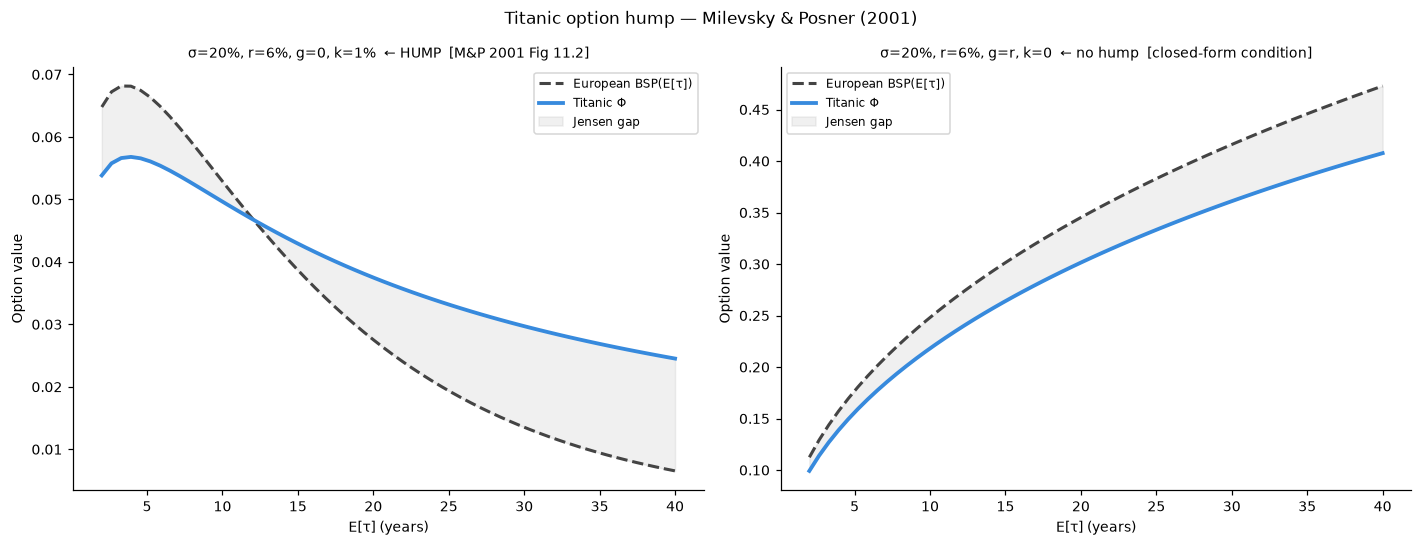

Hump: fee erodes account → optimal E[τ]≈10-15yr. Without fee: both curves monotone.


In [6]:
e_tau, t_vals, e_vals = titanic_hump_data(sigma=0.20, r=0.06, g=0.0, k=0.01, T_max=300.0)
e_tau2, t_vals2, e_vals2 = titanic_hump_data(sigma=0.20, r=0.06, g=0.06, k=0.0, T_max=300.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (tv, ev, params) in zip(
    axes,
    [
        (t_vals, e_vals, "g=0, k=1%  ← HUMP  [M&P 2001 Fig 11.2]"),
        (t_vals2, e_vals2, "g=r, k=0  ← no hump  [closed-form condition]"),
    ],
):
    ax.plot(e_tau, ev, color="#444", lw=2, ls="--", label="European BSP(E[τ])")
    ax.plot(e_tau, tv, color=models["exp"].color, lw=2.5, label="Titanic Φ")
    ax.fill_between(e_tau, tv, ev, alpha=0.12, color="#888", label="Jensen gap")
    ax.set_xlabel("E[τ] (years)")
    ax.set_ylabel("Option value")
    ax.set_title(f"σ=20%, r=6%, {params}", fontsize=9)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("Titanic option hump — Milevsky & Posner (2001)", fontsize=11)
plt.tight_layout()
plt.show()
print("Hump: fee erodes account → optimal E[τ]≈10-15yr. Without fee: both curves monotone.")


## 3. The surrender option — mixed valuation by LSMC

*After Milevsky & Salisbury, "The Real Option to Lapse a Variable Annuity: Can Surrender Charges Complete the Market?"*

Standard derivative-pricing models (Black–Scholes–Merton) assume the option premium is paid in full, upfront. Many insurance contracts with embedded options are instead paid in instalments, through ongoing fees. This seemingly minor change has a profound consequence: it hands the policyholder a *real option to lapse* — the right to walk away precisely when the embedded guarantee is out-of-the-money, thereby avoiding payment for value the holder no longer wants. A holder who lapses and immediately repurchases at every new high can, in principle, ratchet a simple money-back guarantee (a vanilla put) up into a highest-value-achieved guarantee (a lookback put) — a far more expensive promise — without ever paying for the upgrade. The lapse option therefore breaks the hedge. Even when *both* the mortality and the financial markets are complete — so the insurer can fully diversify mortality risk by selling enough policies and replicate any financial payoff — the holder's freedom to lapse *de facto* renders the market incomplete: the contingent claim can no longer be hedged.

Here is the central, counterintuitive result. Frictions — loads, commissions, surrender charges — are normally cast as the *source* of incompleteness: **for this claim, the friction is not what breaks the market — it is the only thing that completes it.** A properly calibrated contingent deferred surrender charge (DSC) is precisely the instrument that funds the guarantee and restores a self-financing hedge. Concretely, the model identifies the $(\pi, \kappa)$ curve that exactly funds the guarantee when the charge is calibrated to the holder's optimal lapse policy. The same curve delivers lower and upper fee bounds, $\pi_L$ and $\pi_U$, outside which the product is unsustainable. Within this framework, lapsation is *rational* when it is immediately followed by a repurchase undertaken solely to reset the basis of the guarantee, and *irrational* when the surrender penalty exceeds the value of the new option.

### Formulation of the hedge portfolio as an American contingent / perpetual claim

We assume a very large pool of insured fund owners — each of whom invests a relatively small amount in the protected mutual fund — so that a fraction $\lambda_t P(\tau \ge t)\,dt$ of the population dies between time $t$ and $t+dt$. This is another way of stating the classical (simplifying) assumption that mortality risk is completely diversifiable, and therefore not priced by the market. As a result, the outflow (payout) due only to death between $t$ and $t+dt$ is precisely

$$
c_t\,dt = V_0\,G(U_t)\,\lambda_t\,P(\tau \ge t)\,dt
$$

where $V_0$ is the (very large) originally invested capital of all the fund owners ($U_t$ being the fund units, $U_0=1$). The hedging portfolio obeys the following SDE (where $c_t\,dt$ acts as a deterministic dividend):

$$
dV_t + c_t\,dt = \alpha_t\,dS_t + \phi_t\,dR_t
$$

The term $\pi_t\,dS_t + \beta_t\,dB_t$ is a self-financing portion, while $c_t\,dt$ represents the (consumption) outflow due to death. The liability floor $L_t$ is

$$
V_t \ge L =
\begin{cases}
V_0(1 - \kappa_t)\,P(\tau \ge T)\,U_t, & 0 \le t \le T,\ \text{(Lapse)}\\[2pt]
V_0\,P(\tau \ge T)\,G(U_T), & t = T,\ \text{(Maturity)}
\end{cases}
$$

The value of the portfolio (assets) must always exceed the liability. The portion $V_0(1 - \kappa_t)P(\tau \ge T)\,U_t$ covers the lapsation value of the fund, for the fraction $P(\tau \ge T)$ still alive, while $V_0\,P(\tau \ge T)\,G(U_T)$ covers the maturity guarantee. The martingale representation of the self-financing hedging portfolio ($V_t + \nu R_t$, with $d\nu = (c_t/R_t)\,dt$ built from the dividends) is

$$
V_0 = M_0 = \tilde{E}_0\!\left[\frac{1}{R_t}(V_t + \nu R_t)\right]
= \tilde{E}_0\!\left[ \frac{V_t}{R_t} + \int_0^t \frac{c_s}{R_s}\,ds \right]
= \tilde{E}_0\!\left[ \frac{V_t}{R_t} + \int_0^t \frac{V_0\,\lambda_s P(\tau \ge T)\,G(U_s)}{R_s}\,ds \right],
$$

for any $t \ge 0$, where $\tilde{E}_t[\,\cdot\,]$ denotes the risk-neutral conditional (on time-$t$) expectation. In words, the discounted value of the hedging portfolio plus the discounted sum of all payments made at death is a martingale. If, for example, the death rate and the continuous insurance charge are set to zero ($\pi_t = 0,\ \mu_t = 0$), while the deferred surrender charge is set at $100\%$ ($\kappa_t = 1$), the equation with $t = T$ collapses to

$$
V_0 = \tilde{E}_0\!\left[ \frac{\max(1, S_T)}{R_T} \right],
$$

the Black–Scholes–Merton risk-neutral expectation for an at-the-money European put plus a position in the underlying.

### The DSC / fees optimal curve

If the insurance charge is exactly $\pi_U$, the optimal lapsation level hits one: one should lapse the contract instantaneously after purchasing it — i.e. the contract should never be purchased. Equivalently, if $\pi > \pi_U$ the contract is not viable, since no rational individual would ever hold it. All combinations of $(\pi, \kappa)$ on the curve represent an appropriate charge for the embedded option: there is **no unique price** for the contingent claim. Any such pair — or any combination on the curve in between — creates enough money to construct a self-financing portfolio to hedge the option. The optimal lapsation policy will depend on which pair is chosen. Transaction costs (frictions) complete the market and allow a self-financing strategy to exist; that strategy yields not a unique price but a *menu* of charges that can support the claim.

### Hedging the optimal lapsation boundary

The effect of lapses and surrenders on variable annuities is ambiguous. Early termination reduces fee income and may leave the guarantee under-funded, effectively creating an incomplete market. Under rational lapsation, one can study the optimal time to lapse and its impact on guarantee valuation. In practice, re-establishing the cost basis through selling and repurchasing incurs a load proportional to the account value, declining over time. **Assuming full rationality, the insurer might hedge by buying an up-and-out put whose knockout barrier is the optimal lapsation boundary.**

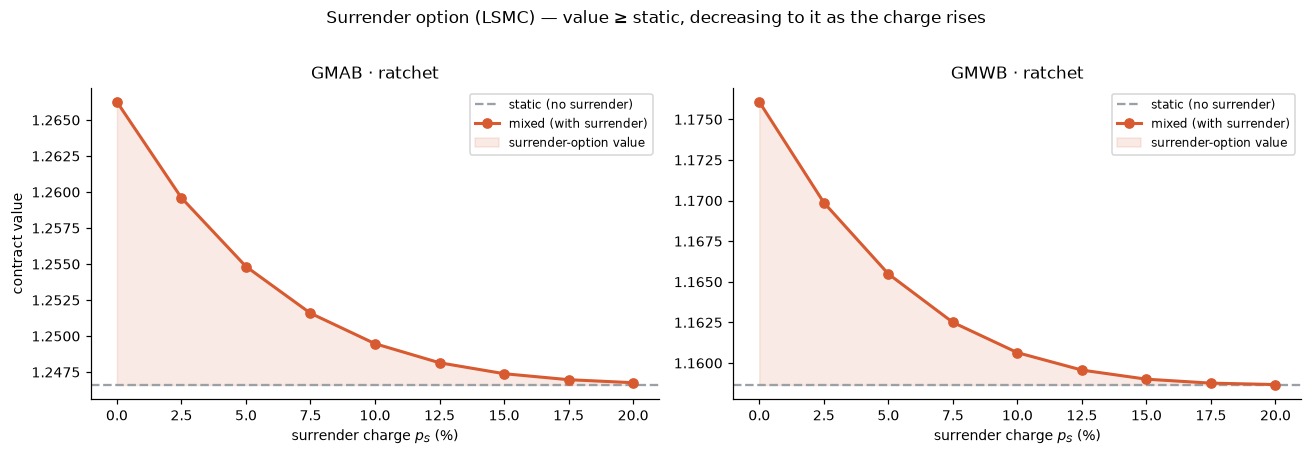

In [7]:
sde, mkt = world()
fund = sde["eq"]
P = 1.0
pS = np.linspace(0.0, 0.20, 9)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for j, (pname, cls) in enumerate([("GMAB", GMABAnnuity), ("GMWB", GMWBAnnuity)]):
    static = float(
        cls(
            fund=fund,
            living_floor=GuaranteeFloor([Ratchet()], G0=P),
            premium=P,
            maturity=10.0,
            marketkeys=MarketKeys(discount="ois"),
        ).price(mkt)[0].mean()
    )
    mixed = []
    for p in pS:
        gm = cls(
            fund=fund,
            living_floor=GuaranteeFloor([Ratchet()], G0=P),
            surrender_floor=GuaranteeFloor([Fixed()], G0=P),
            p_S=float(p),
            premium=P,
            maturity=10.0,
            marketkeys=MarketKeys(discount="ois"),
        )
        gm.list_mixed()
        mixed.append(float(gm.price(mkt)[0].mean()))
    mixed = np.array(mixed)
    ax[j].axhline(static, color=GREY, ls="--", lw=1.5, label="static (no surrender)")
    ax[j].plot(pS * 100, mixed, "o-", color=O, lw=2, label="mixed (with surrender)")
    ax[j].fill_between(pS * 100, static, mixed, color=O, alpha=0.12,
                       label="surrender-option value")
    ax[j].set_xlabel("surrender charge $p_S$ (%)")
    ax[j].set_title(f"{pname} · ratchet")
    ax[j].legend(fontsize=8)
ax[0].set_ylabel("contract value")
fig.suptitle(
    "Surrender option (LSMC) — value ≥ static, decreasing to it as the charge rises",
    y=1.02,
)
fig.tight_layout()
plt.show()

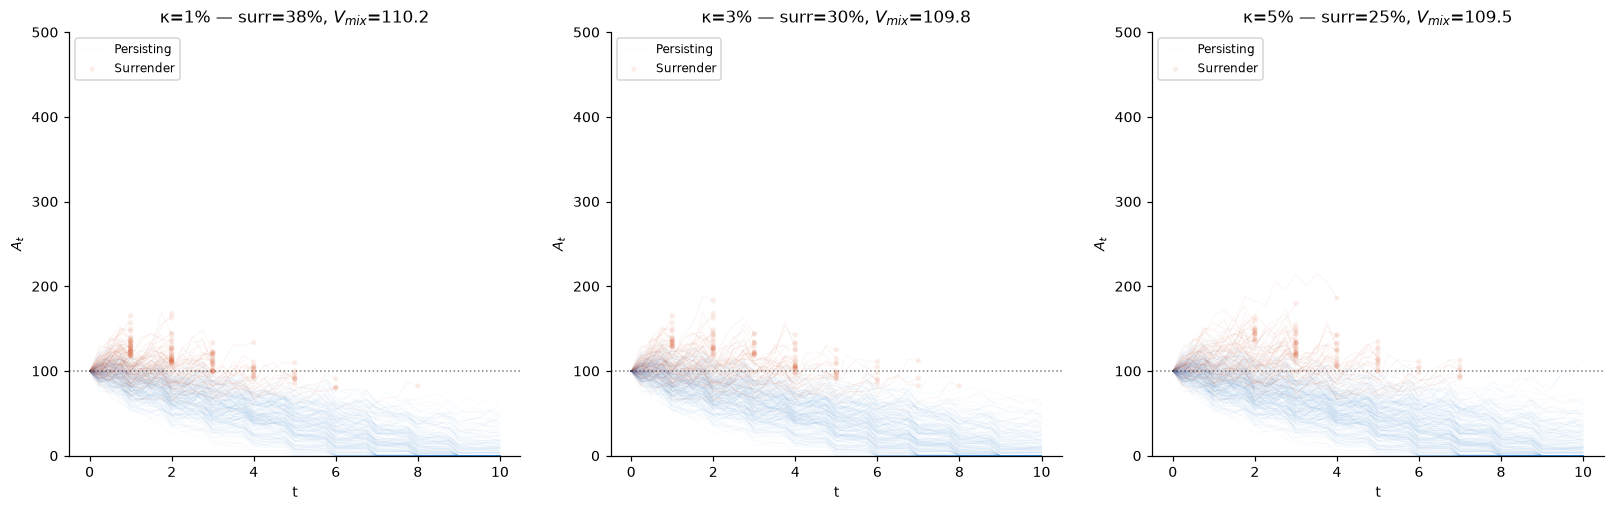

In [29]:
# ── Surrender geography — GMWB, fee φ=3%, varying surrender charge κ ───────────
# API migration: GeometricBrownianProcess→GeometricBrownianFactor,
# CorrelatedProcesses→SDESystem, VariableAnnuity+GMWB→GMWBAnnuity.
#
# Return-of-premium GMWB (Fixed living floor), account-only / Bacinello surrender
# (no surrender floor).  The current GMxBAnnuity exposes only ``_last_surrendered``
# after a mixed price, and its built-in mixed pricer uses a *penalty-independent*
# surrender decision (chosen for dominance/monotonicity), so that mask cannot move
# with κ.  The holder's surrender *behaviour* is penalty-dependent, so we
# reconstruct it here — the library's own documented (Bacinello/Fontana) penalised
# first-crossing rule — on the public ``_paths`` state, without touching the
# library.  V_mix is the static value plus the discounted surrender-option premium
# from that same rule, so the panel's surr% and V_mix are internally consistent.
from qabit.core.analytics.common.lsmc import _poly_basis, _ols
from qabit.tools.util import to_path, nearest_index

P0, r0, T_w = 100.0, 0.03, 10.0
N_SIM, SEED = 50_000, 11

# single-fund, flat-rate world (current qabit API)
gbm_sg = GeometricBrownianFactor(sigma=0.20, s0=P0, mu=r0, rate=None)
cal_sg = EventCalendar.from_horizon(T_w, dt=0.25)
sde_sg = SDESystem({"eq": gbm_sg})
sde_sg.simulate(cal_sg, n_paths=N_SIM, seed=SEED)
fund_sg = sde_sg["eq"]
mkt_sg = Market(discount={"ois": DiscountCurve.flat(r0)})


def _surrender_geography(va, market):
    """Penalised (Bacinello/Fontana) first-crossing surrender, replayed on the
    model's public state — read-only use of ``_paths`` and the LSMC helpers; the
    library is not modified.  Returns per path: surrender anniversary index k
    (or -1), the discounted surrender premium, the fine-grid account A_t, the
    per-anniversary pre-withdrawal account A_pre, and the index maps."""
    pp = va._paths(market)
    disc = va.marketkeys.discount_curve(market)
    Np, dtype, device = pp["Np"], pp["dtype"], pp["device"]
    anniv = pp["anniv"]; N = int(round(va.maturity))
    DF = {n: to_path(disc.df(float(n)), Np, dtype, device) for n in anniv}
    surr_set = {int(round(s)) for s in va.surrender_schedule}

    # contractual (no-surrender) cashflows: withdrawals + terminal guarantee
    cf = [torch.zeros(Np, dtype=dtype, device=device) for _ in anniv]
    for k in range(1, len(anniv)):
        n = anniv[k]
        cf[k] = va.living_cashflow(float(n), pp["A_pre"][k], pp["GX_m"][k])
        if int(round(n)) == N:
            cf[k] = cf[k] + va.terminal_cashflow(pp["A_post"][k], pp["GX_p"][k])
    pv0 = [cf[k] * DF[anniv[k]] for k in range(len(anniv))]
    suffix = [None] * len(anniv); acc = torch.zeros(Np, dtype=dtype, device=device)
    for k in range(len(anniv) - 1, -1, -1):
        acc = acc + pv0[k]; suffix[k] = acc.clone()

    def feats(k):
        cols = [pp["A_pre"][k] / va.premium]
        if float(pp["GS_m"][k].abs().max()) > 1e-9:        # non-degenerate G^S only
            cols.append(pp["GS_m"][k] / va.premium)
        return torch.stack(cols, dim=1)

    # penalty-independent contractual continuation Ĉ_k (regressed)
    chat = {}
    for k, n in enumerate(anniv):
        if int(round(n)) not in surr_set:
            continue
        Y = suffix[k] / DF[anniv[k]].clamp(min=1e-12)
        beta = _ols(_poly_basis(feats(k), degree=2), Y)
        chat[k] = _poly_basis(feats(k), degree=2) @ beta

    # first admissible date where the *penalised* surrender value beats Ĉ_k
    chosen = torch.full((Np,), -1, dtype=torch.long, device=device)
    for k in [k for k in range(len(anniv)) if k in chat]:
        sv_pen = (1.0 - va.p_S) * torch.maximum(pp["A_pre"][k], pp["GS_m"][k])
        crosses = (sv_pen > chat[k]) & (chosen < 0)
        chosen = torch.where(crosses, torch.full_like(chosen, k), chosen)

    # discounted surrender-option premium per path (≥0), booked at the chosen date
    prem = torch.zeros(Np, dtype=dtype, device=device)
    for k in [k for k in range(len(anniv)) if k in chat]:
        sel = chosen == k
        if bool(sel.any()):
            sv_pen = (1.0 - va.p_S) * torch.maximum(pp["A_pre"][k], pp["GS_m"][k])
            gain = (sv_pen - chat[k]).clamp(min=0.0) * DF[anniv[k]]
            prem = torch.where(sel, gain, prem)

    # exact fine-grid account, reproducing the model's growth/withdrawal recursion
    st = va.fund.get_state(); S = st.paths.float()
    if S.dim() == 3:
        S = S[:, :, 0]
    dates = st.dates.float()
    growth = (S / S[:, 0:1].clamp(min=1e-12)) * torch.exp(-va.alpha * dates).unsqueeze(0)
    aidx = [nearest_index(dates.tolist(), float(t)) for t in anniv]
    A_fine = torch.empty_like(S); A_fine[:, 0] = pp["A_post"][0]
    for k in range(1, len(anniv)):
        lo, hi = aidx[k - 1], aidx[k]
        A_fine[:, lo:hi + 1] = pp["A_post"][k - 1].unsqueeze(1) \
            * growth[:, lo:hi + 1] / growth[:, lo:lo + 1].clamp(min=1e-12)

    return chosen, prem, A_fine, dates, pp["A_pre"], anniv, aidx


kappas_sg = [0.01, 0.03, 0.05]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, kap in zip(axes, kappas_sg):

    va = GMWBAnnuity(
        fund=fund_sg,
        living_floor=GuaranteeFloor([RollUp(0.02)], G0=P0),   # return-of-premium GMWB
        surrender_floor=None,                            # account-only (Bacinello)
        premium=P0, maturity=T_w, alpha=0.01, p_S=kap,
        marketkeys=MarketKeys(discount="ois"),
    )
    v_static = va.price(mkt_sg)[0].mean().item()         # static value (no surrender)

    chosen, prem, A, dates, A_pre, anniv, aidx = _surrender_geography(va, mkt_sg)
    surr = chosen >= 0
    vm = v_static + float(prem.mean())                   # mixed = static + surrender premium
    dates_np = dates.numpy()

    # sample paths — surrendered (orange, truncated at surrender) vs persisting (blue)
    step = max(1, N_SIM // 300)
    first_dot = True

    for i in range(0, N_SIM, step):
        if surr[i]:
            e_s = aidx[int(chosen[i])]

            # plot until surrender
            ax.plot(
                dates_np[:e_s + 1],
                A[i, :e_s + 1].numpy(),
                color=O,
                alpha=0.08,
                lw=0.5,
            )

            # mark surrender point
            ax.scatter(
                dates_np[e_s],
                A[i, e_s].item(),
                s=12,
                color=O,
                edgecolors="none",
                alpha=0.1,
                zorder=5,
                label="Surrender" if first_dot else None,
            )
            first_dot = False

        else:
            ax.plot(
                dates_np,
                A[i].numpy(),
                color=B,
                alpha=0.04,
                lw=0.5,
                label="Persisting" if i == 0 else None,
            )

    pct = float(surr.float().mean()) * 100
    ax.axhline(P0, color='k', ls=':', lw=1, alpha=0.5)
    ax.set_title(f'κ={kap*100:.0f}% — surr={pct:.0f}%, $V_{{mix}}$={vm:.1f}', fontsize=11)
    ax.set_xlabel('t')
    ax.set_ylabel('$A_t$')
    ax.legend(fontsize=8, loc='upper left')
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, 5 * P0)


    



# Fee–Penalty Surface: $V_0^{\text{mixed}}(\varphi, \kappa)$
A 3D surface showing how the GMWB contract value changes across the
full (fee, penalty) plane.  The Bacinello inequality ($V_{mixed} \ge V_{static}$)
and penalty monotonicity are visible as structural features of the surface.

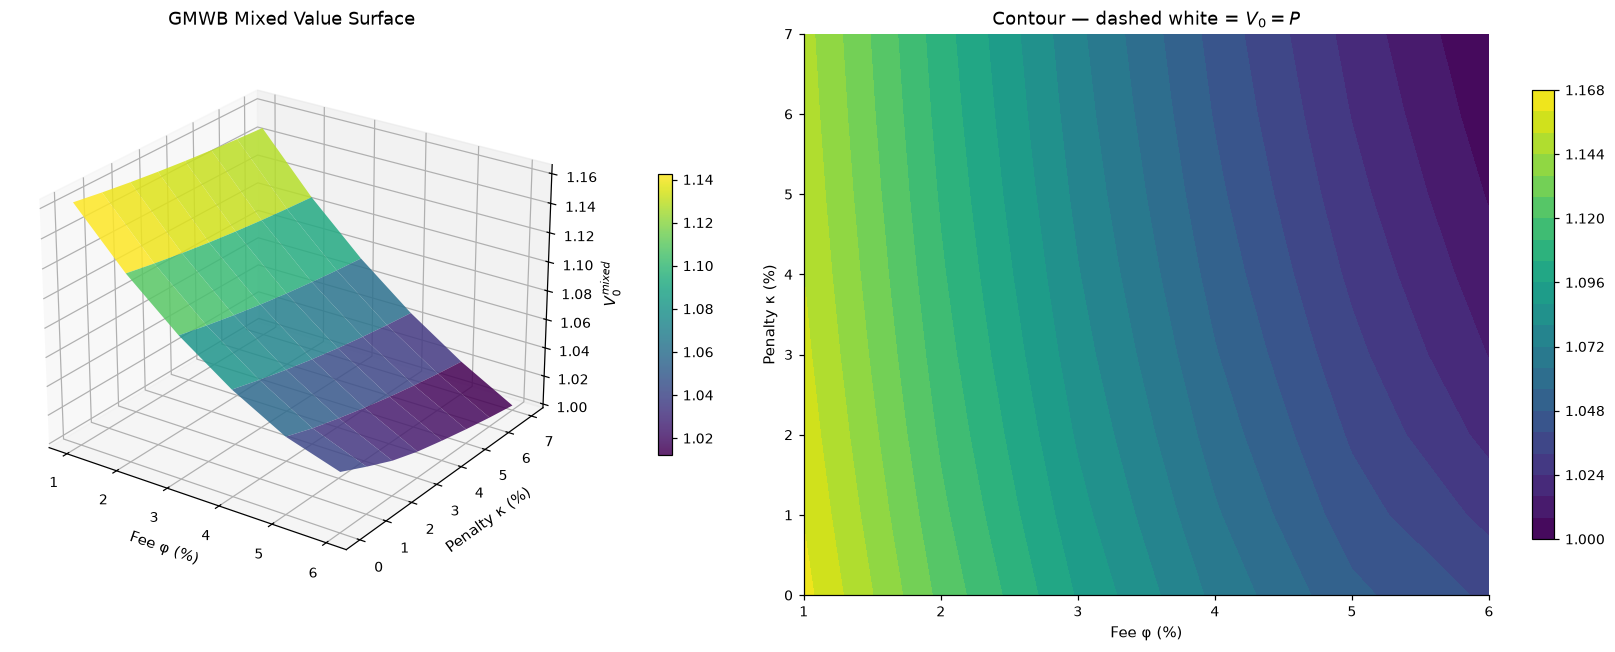

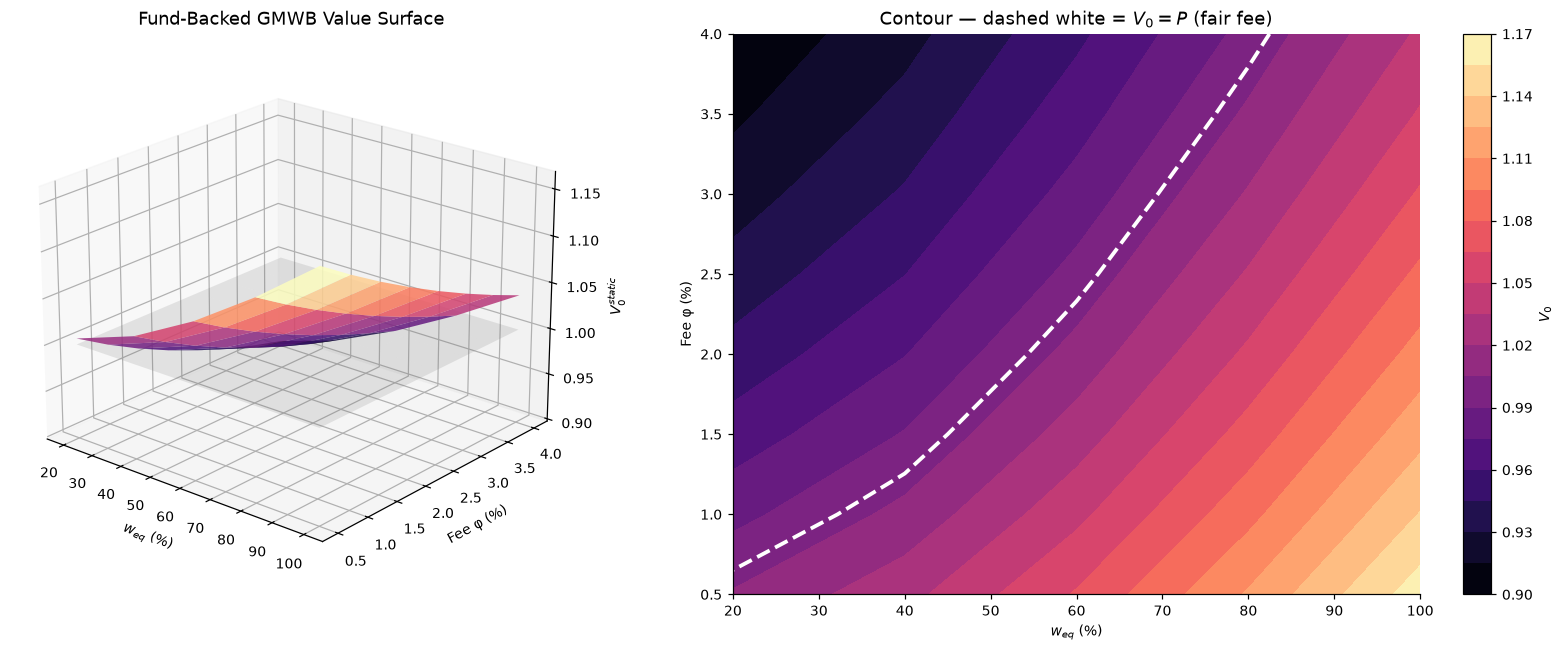

In [9]:
# ── Fee–penalty surface for a GMWB ────────────────────────────────────────────
# Constants for the surface experiments (a flat-rate, single-fund world).
P0, r0, T_w = 1.0, 0.03, 10.0
N_SIM, SEED = 50_000, 11

gbm = GeometricBrownianFactor(sigma=0.20, s0=P0, mu=r0, rate=None)
cal = EventCalendar.from_horizon(T_w, dt=0.25)
sde = SDESystem({"eq": gbm})
sde.simulate(cal, n_paths=N_SIM, seed=SEED)
fund = sde["eq"]
mkt = Market(discount={"ois": DiscountCurve.flat(r0)})


def make_gmwb(fund, fee, p_S=0.0):
    """Return-of-premium GMWB with a fixed surrender floor."""
    return GMWBAnnuity(
        fund=fund,
        living_floor=GuaranteeFloor([Ratchet()], G0=P0),
        surrender_floor=GuaranteeFloor([Fixed()], G0=P0),
        premium=P0, maturity=T_w, alpha=fee, p_S=p_S,
        marketkeys=MarketKeys(discount="ois"),
    )


fees_grid = np.arange(1.0, 6.5, 1.0)   # fee φ in %
pens_grid = np.arange(0.0, 8.0, 1.0)   # surrender charge κ in %
F, K = np.meshgrid(fees_grid, pens_grid)
V_mixed = np.zeros_like(F)
V_static = np.zeros_like(F)

for i, fee_pct in enumerate(fees_grid):
    fv = fee_pct / 100.0
    vs = make_gmwb(fund, fv).price(mkt)[0].mean().item()
    for j, pen_pct in enumerate(pens_grid):
        V_static[j, i] = vs
        va_m = make_gmwb(fund, fv, p_S=pen_pct / 100.0)
        va_m.list_mixed()
        V_mixed[j, i] = va_m.price(mkt)[0].mean().item()

fig = plt.figure(figsize=(16, 6))

# 3D surface
ax1 = fig.add_subplot(121, projection="3d")
surf = ax1.plot_surface(F, K, V_mixed, cmap=cm.viridis, alpha=0.85,
                        edgecolor="none", antialiased=True)
ax1.set_xlabel("Fee φ (%)", fontsize=10)
ax1.set_ylabel("Penalty κ (%)", fontsize=10)
ax1.set_zlabel("$V_0^{mixed}$", fontsize=10)
ax1.set_title("GMWB Mixed Value Surface", fontsize=12)
ax1.view_init(elev=25, azim=-55)
fig.colorbar(surf, ax=ax1, shrink=0.5, pad=0.1)

# Contour with fair-fee line
ax2 = fig.add_subplot(122)
cs = ax2.contourf(F, K, V_mixed, levels=20, cmap=cm.viridis)
ax2.contour(F, K, V_mixed, levels=[P0], colors="white", linewidths=2.5, linestyles="--")
ax2.set_xlabel("Fee φ (%)", fontsize=10)
ax2.set_ylabel("Penalty κ (%)", fontsize=10)
ax2.set_title("Contour — dashed white = $V_0 = P$", fontsize=12)
fig.colorbar(cs, ax=ax2, shrink=0.8)

plt.tight_layout()
plt.savefig(os.path.join(TMP, "07_fee_penalty_surface.png"), bbox_inches="tight")
plt.show()

# ── Fund-backed GMWB: value across (equity weight, fee) ───────────────────────
sigma_eq, sigma_bd = 0.20, 0.07
C = [[1.0, 0.2], [0.2, 1.0]]   # equity–bond correlation

w_grid_f = np.arange(0.2, 1.01, 0.2)
fees_fund = np.arange(0.5, 4.1, 0.5)
W_F, PHI_F = np.meshgrid(w_grid_f, fees_fund)
V_fund = np.zeros_like(W_F)

for i, w_eq in enumerate(w_grid_f):
    w_bd = 1.0 - w_eq
    eq = GeometricBrownianFactor(sigma=sigma_eq, s0=P0, mu=r0, rate=None)
    bd = GeometricBrownianFactor(sigma=sigma_bd, s0=P0, mu=r0, rate=None)
    sde_f = SDESystem({"eq": eq, "bd": bd}, correlation=C)
    sde_f.simulate(cal, n_paths=N_SIM, seed=SEED)
    if w_eq < 1.0 - 1e-6:
        proc = Fund(
            {"eq": sde_f["eq"], "bd": sde_f["bd"]},
            weights={"eq": float(w_eq), "bd": float(w_bd)}, f0=P0,
        ).build()
    else:
        proc = sde_f["eq"]
    for j, fee_pct in enumerate(fees_fund):
        va = GMWBAnnuity(
            fund=proc, living_floor=GuaranteeFloor([Ratchet()], G0=P0),
            premium=P0, maturity=T_w, alpha=fee_pct / 100.0,
            marketkeys=MarketKeys(discount="ois"),
        )
        V_fund[j, i] = va.price(mkt)[0].mean().item()

fig = plt.figure(figsize=(16, 6))

ax1 = fig.add_subplot(121, projection="3d")
surf = ax1.plot_surface(W_F * 100, PHI_F, V_fund, cmap=cm.magma, alpha=0.85,
                        edgecolor="none")
ax1.plot_surface(W_F * 100, PHI_F, np.full_like(V_fund, P0), alpha=0.15, color="gray")
ax1.set_xlabel("$w_{eq}$ (%)")
ax1.set_ylabel("Fee φ (%)")
ax1.set_zlabel("$V_0^{static}$")
ax1.set_title("Fund-Backed GMWB Value Surface", fontsize=12)
ax1.view_init(elev=22, azim=-50)

ax2 = fig.add_subplot(122)
cs = ax2.contourf(W_F * 100, PHI_F, V_fund, levels=20, cmap=cm.magma)
ax2.contour(W_F * 100, PHI_F, V_fund, levels=[P0], colors="white",
            linewidths=2.5, linestyles="--")
ax2.set_xlabel("$w_{eq}$ (%)")
ax2.set_ylabel("Fee φ (%)")
ax2.set_title("Contour — dashed white = $V_0 = P$ (fair fee)", fontsize=12)
fig.colorbar(cs, ax=ax2, label="$V_0$")

plt.tight_layout()
plt.savefig(os.path.join(TMP, "07_fund_value_surface.png"), bbox_inches="tight")
plt.show()


## 4. Reproduction tables (Bacinello / Fontana)

The fee × penalty grids below reproduce the structural tables of the source
papers under this unified framework. Each table is a single $(\text{fee}, p_S)$
sweep priced by mixed LSMC, with the static value in the last column. Two
results are visible throughout: the mixed value **dominates** the static value
($V^{\text{mixed}}\ge V^{\text{static}}$), and it **decreases monotonically** in
the surrender charge $p_S$, converging to the static value as the charge grows.

> The excess-withdrawal penalty $\beta$ of the original papers is intentionally
> dropped (see §10): behavioural early exit is priced by the surrender charge
> $p_S$ alone.

In [10]:
# ── Table 12 — GMAB & GMDB roll-up δ=2% (mixed) ───────────────────────────────
# A GMAB carrying a *separable* GMDB: both the living floor G^X and the death
# floor G^D roll up at δ=2%.  Mortality enters through a Gompertz hazard factor
# simulated alongside the equity, read as a StochasticHazardCurve.
P0, r0, SEED = 1.0, 0.03, 11
T5, N_T = 5.0, 8000
delta12 = 0.02
fees_12, pens_12 = [6, 7, 8, 9, 10, 11], [0, 1, 2, 3, 4, 5]

cal_5 = EventCalendar.from_horizon(T5, dt=0.25)
sde_5 = SDESystem(
    {
        "eq": GeometricBrownianFactor(sigma=0.20, s0=P0, mu=r0, rate=None),
        "mort": GompertzHazardFactor(m=80.0, b=9.5, entry_age=ENTRY_AGE),
    }
)
sde_5.simulate(cal_5, n_paths=N_T, seed=SEED)
fund_5 = sde_5["eq"]
mkt_5 = Market(
    discount={"ois": DiscountCurve.flat(r0)},
    hazard={"mort": StochasticHazardCurve(sde_5["mort"])},
)
mk_5 = MarketKeys(discount="ois", hazard="mort")


def gmab_gmdb(fee, p_S=0.0):
    return GMABAnnuity(
        fund=fund_5,
        living_floor=GuaranteeFloor([RollUp(delta12)], G0=P0),
        death_floor=GuaranteeFloor([RollUp(delta12)], G0=P0),
        surrender_floor=GuaranteeFloor([Fixed()], G0=P0),
        premium=P0, maturity=T5, alpha=fee, p_S=p_S,
        marketkeys=mk_5, seed=SEED,
    )


print("Table 12: GMAB & GMDB, δ=2%")
hdr = f"{'f%':>4}" + "".join(f"  {'p='+str(p)+'%':>7}" for p in pens_12) + f"  {'V_stat':>8}"
print(hdr); print("-" * len(hdr))
results_12 = {}
for fee_pct in fees_12:
    fv = fee_pct / 100.0
    vs = gmab_gmdb(fv).price(mkt_5)[0].mean().item()
    row = []
    print(f"{fee_pct:>4}", end="")
    for p_pct in pens_12:
        va_m = gmab_gmdb(fv, p_S=p_pct / 100.0)
        va_m.list_mixed()
        vm = va_m.price(mkt_5)[0].mean().item()
        row.append(vm)
        print(f"  {vm:>7.3f}", end="")
    print(f"  {vs:>8.3f}")
    results_12[fee_pct] = (row, vs)

Table 12: GMAB & GMDB, δ=2%
  f%     p=0%     p=1%     p=2%     p=3%     p=4%     p=5%    V_stat
--------------------------------------------------------------------
   6    1.051    1.045    1.040    1.037    1.033    1.030     1.017
   7    1.042    1.036    1.031    1.027    1.024    1.021     1.004
   8    1.034    1.027    1.023    1.019    1.016    1.013     0.994
   9    1.027    1.020    1.015    1.012    1.008    1.005     0.986
  10    1.021    1.013    1.008    1.005    1.002    0.999     0.979
  11    1.015    1.007    1.001    0.998    0.996    0.993     0.973


In [11]:
# ── Table 14 — GMWB T=10 (mixed), with paper reference values ─────────────────
# Return-of-premium GMWB; the excess-withdrawal penalty β of the original paper
# is dropped (this framework prices behavioural exit through the surrender
# charge p_S only — see §10).  paper_14 holds the published reference grid.
P0, r0, SEED = 1.0, 0.03, 11
T14, N_T = 10.0, 8000
sigma0 = 0.20
fees_14, pens_14 = [1, 2, 3, 4, 5, 6], [0, 1, 2, 3, 4, 5]
cal_14 = EventCalendar.from_horizon(T14, dt=0.25)
sde_14 = SDESystem({"eq": GeometricBrownianFactor(sigma=sigma0, s0=P0, mu=r0, rate=None)})
sde_14.simulate(cal_14, n_paths=N_T, seed=SEED)
fund_14 = sde_14["eq"]
mkt_14 = Market(discount={"ois": DiscountCurve.flat(r0)})


def gmwb_14(fund, fee, p_S=0.0):
    return GMWBAnnuity(
        fund=fund,
        living_floor=GuaranteeFloor([Fixed()], G0=P0),
        surrender_floor=GuaranteeFloor([Fixed()], G0=P0),
        premium=P0, maturity=T14, alpha=fee, p_S=p_S,
        marketkeys=MarketKeys(discount="ois"),
    )


print("Table 14: GMWB T=10")
hdr = f"{'f%':>4}" + "".join(f"  {'p='+str(p)+'%':>7}" for p in pens_14) + f"  {'V_stat':>7}"
print(hdr); print("-" * len(hdr))
results_14 = {}
for fee_pct in fees_14:
    fv = fee_pct / 100.0
    vs = gmwb_14(fund_14, fv).price(mkt_14)[0].mean().item()
    row = []
    print(f"{fee_pct:>4}", end="")
    for p_pct in pens_14:
        va_m = gmwb_14(fund_14, fv, p_S=p_pct / 100.0)
        va_m.list_mixed()
        vm = va_m.price(mkt_14)[0].mean().item()
        row.append(vm)
        print(f"  {vm:>7.3f}", end="")
    print(f"  {vs:>7.3f}")
    results_14[fee_pct] = (row, vs)

Table 14: GMWB T=10
  f%     p=0%     p=1%     p=2%     p=3%     p=4%     p=5%   V_stat
-------------------------------------------------------------------
   1    1.074    1.064    1.056    1.049    1.044    1.040    1.032
   2    1.055    1.044    1.035    1.027    1.020    1.013    0.995
   3    1.048    1.037    1.027    1.016    1.007    0.999    0.964
   4    1.042    1.032    1.022    1.011    1.001    0.991    0.939
   5    1.038    1.027    1.017    1.007    0.996    0.986    0.919
   6    1.033    1.023    1.012    1.002    0.992    0.981    0.902


In [12]:
# ── Table 15 — GMWB, p=3%, sensitivity to the risk-free rate ──────────────────
# A higher rate lifts the drift (richer account) but also discounts harder; the
# mixed value reflects the net effect at a fixed 3% surrender charge.
fees_15 = [1, 2, 3, 4, 5, 6]
rate_levels = [0.01, 0.02, 0.03, 0.04, 0.05]
pens_fix = 0.03

print("Table 15: GMWB, p=3%, varying rate")
hdr = f"{'f%':>4}" + "".join(f"  {'r='+str(int(rl*100))+'%':>8}" for rl in rate_levels)
print(hdr); print("-" * len(hdr))
results_15 = {}
for fee_pct in fees_15:
    fv = fee_pct / 100.0
    row = []
    print(f"{fee_pct:>4}", end="")
    for r_lev in rate_levels:
        gbm_r = GeometricBrownianFactor(sigma=sigma0, s0=P0, mu=r_lev, rate=None)
        sde_r = SDESystem({"eq": gbm_r})
        sde_r.simulate(EventCalendar.from_horizon(T14, dt=0.25), n_paths=N_T, seed=SEED)
        mkt_r = Market(discount={"ois": DiscountCurve.flat(r_lev)})
        va_m = gmwb_14(sde_r["eq"], fv, p_S=pens_fix)
        va_m.list_mixed()
        vm = va_m.price(mkt_r)[0].mean().item()
        row.append(vm)
        print(f"  {vm:>8.2f}", end="")
    print()
    results_15[fee_pct] = row

Table 15: GMWB, p=3%, varying rate
  f%      r=1%      r=2%      r=3%      r=4%      r=5%
------------------------------------------------------
   1      1.09      1.07      1.05      1.04      1.02
   2      1.07      1.04      1.03      1.02      1.01
   3      1.05      1.03      1.02      1.01      1.01
   4      1.04      1.02      1.01      1.01      1.00
   5      1.02      1.01      1.01      1.00      1.00
   6      1.02      1.01      1.00      1.00      0.99


In [14]:
# ── Table 16 — GMWB, p=3%, sensitivity to fund volatility ─────────────────────
# The volatility levels are quoted as variance ζ_K (so σ = √ζ_K).  More vol → a
# more valuable embedded guarantee, monotone in the fee at a fixed 3% charge.
vol_levels = [0.0, 0.02, 0.04, 0.06, 0.08]   # ζ_K (variance); σ = √ζ_K
fees_16 = [1, 2, 3, 4, 5, 6]

print("Table 16: GMWB, p=3%, varying vol (σ² = ζ_K)")
hdr = f"{'f%':>4}" + "".join(f"  {'v='+str(int(v*100))+'%':>8}" for v in vol_levels)
print(hdr); print("-" * len(hdr))
results_16 = {}
for fee_pct in fees_16:
    fv = fee_pct / 100.0
    row = []
    print(f"{fee_pct:>4}", end="")
    for v_lev in vol_levels:
        sig = math.sqrt(max(v_lev, 1e-6))
        gbm_v = GeometricBrownianFactor(sigma=sig, s0=P0, mu=r0, rate=None)
        sde_v = SDESystem({"eq": gbm_v})
        sde_v.simulate(EventCalendar.from_horizon(T14, dt=0.25), n_paths=N_T, seed=SEED)
        mkt_v = Market(discount={"ois": DiscountCurve.flat(r0)})
        va_m = gmwb_14(sde_v["eq"], fv, p_S=pens_fix)
        va_m.list_mixed()
        vm = va_m.price(mkt_v)[0].mean().item()
        row.append(vm)
        print(f"  {vm:>8.3f}", end="")
    print()
    results_16[fee_pct] = row



Table 16: GMWB, p=3%, varying vol (σ² = ζ_K)
  f%      v=0%      v=2%      v=4%      v=6%      v=8%
------------------------------------------------------
   1     0.960     1.012     1.049     1.079     1.107
   2     0.951     0.999     1.027     1.055     1.079
   3     0.942     0.994     1.016     1.037     1.060
   4     0.941     0.989     1.011     1.028     1.044
   5     0.941     0.985     1.007     1.023     1.037
   6     0.941     0.981     1.002     1.018     1.032


### Takeaway

One contract class, three composable floors, two valuation schemes — all driven by the
same stochastic factors. The framework reproduces the textbook structural results (floor
cost ordering, Bacinello surrender monotonicity, fair-fee solve) and hands a
fully-specified, path-dependent liability to the deep hedger in notebook 04.